# Analiza wykorzystania pamięci RAM dla VGG16

Celem eksperymentu jest sprawdzenie, jak zmienia się zużycie pamięci RAM podczas pracy z modelem VGG16.

Eksperyment mierzy pamięć dla kilku etapów:

1. wczytanie zbioru CIFAR-10
2. utworzenie modelu VGG16
3. trening modelu VGG16
4. ewaluacja modelu na zbiorze testowym

In [1]:
from pathlib import Path
import os
import time
import gc
import threading

import pandas as pd
import matplotlib.pyplot as plt

import torch
import psutil
import adom_library as adom

adom.show_device()

RESULTS_DIR = Path("experiments_results")
RESULTS_DIR.mkdir(exist_ok=True)

RESULTS_PATH = RESULTS_DIR / "results_vgg16_ram_analysis.csv"

cuda


## Parametry eksperymentu

In [2]:
MODEL_TYPE = "VGG16"
EPOCHS = 1
BATCH_SIZE = 64
DROPOUT_VALUE = None

## Funkcje pomocnicze do pomiaru RAM

Funkcja `measure_memory_usage(...)` uruchamia wskazaną operację i w tle próbuje mierzyć maksymalne zużycie pamięci RAM procesu Pythona. Zwraca wynik operacji oraz słownik z pomiarem pamięci.

Dodatkowo, jeżeli dostępna jest karta CUDA, zapisywane są także przybliżone wartości wykorzystania pamięci GPU.

In [3]:
process = psutil.Process(os.getpid())


def get_ram_mb():
    return process.memory_info().rss / (1024 ** 2)


def get_gpu_memory_mb():
    if not torch.cuda.is_available():
        return {
            "gpu_allocated_mb": None,
            "gpu_reserved_mb": None,
            "gpu_peak_allocated_mb": None,
            "gpu_peak_reserved_mb": None,
        }

    return {
        "gpu_allocated_mb": torch.cuda.memory_allocated() / (1024 ** 2),
        "gpu_reserved_mb": torch.cuda.memory_reserved() / (1024 ** 2),
        "gpu_peak_allocated_mb": torch.cuda.max_memory_allocated() / (1024 ** 2),
        "gpu_peak_reserved_mb": torch.cuda.max_memory_reserved() / (1024 ** 2),
    }


def cleanup_memory():
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()


def measure_memory_usage(stage_name, operation, sample_interval=0.05):
    cleanup_memory()

    if torch.cuda.is_available():
        torch.cuda.reset_peak_memory_stats()

    ram_before = get_ram_mb()
    peak_ram = ram_before
    stop_sampling = False

    def sampler():
        nonlocal peak_ram, stop_sampling
        while not stop_sampling:
            current_ram = get_ram_mb()
            if current_ram > peak_ram:
                peak_ram = current_ram
            time.sleep(sample_interval)

    thread = threading.Thread(target=sampler)
    thread.daemon = True

    start_time = time.time()
    thread.start()

    result = None
    error = None

    try:
        result = operation()
    except Exception as exc:
        error = exc
    finally:
        stop_sampling = True
        thread.join()

    elapsed_time = time.time() - start_time
    ram_after = get_ram_mb()
    gpu = get_gpu_memory_mb()

    metrics = {
        "stage": stage_name,
        "ram_before_mb": ram_before,
        "ram_after_mb": ram_after,
        "ram_peak_mb": peak_ram,
        "ram_peak_increase_mb": peak_ram - ram_before,
        "time_seconds": elapsed_time,
        **gpu,
    }

    if error is not None:
        raise error

    return result, metrics


def print_metrics(metrics):
    print(f"Etap: {metrics['stage']}")
    print(f"RAM przed: {metrics['ram_before_mb']:.2f} MB")
    print(f"RAM po: {metrics['ram_after_mb']:.2f} MB")
    print(f"RAM peak: {metrics['ram_peak_mb']:.2f} MB")
    print(f"Wzrost peak RAM: {metrics['ram_peak_increase_mb']:.2f} MB")
    print(f"Czas: {metrics['time_seconds']:.2f} s")

    if metrics["gpu_peak_allocated_mb"] is not None:
        print(f"GPU peak allocated: {metrics['gpu_peak_allocated_mb']:.2f} MB")
        print(f"GPU peak reserved: {metrics['gpu_peak_reserved_mb']:.2f} MB")

## Pomiar początkowy

In [4]:
initial_metrics = {
    "stage": "Stan początkowy",
    "ram_before_mb": get_ram_mb(),
    "ram_after_mb": get_ram_mb(),
    "ram_peak_mb": get_ram_mb(),
    "ram_peak_increase_mb": 0.0,
    "time_seconds": 0.0,
    **get_gpu_memory_mb(),
}

measurements = [initial_metrics]
print_metrics(initial_metrics)

Etap: Stan początkowy
RAM przed: 528.77 MB
RAM po: 528.77 MB
RAM peak: 528.77 MB
Wzrost peak RAM: 0.00 MB
Czas: 0.00 s
GPU peak allocated: 0.00 MB
GPU peak reserved: 0.00 MB


## Wczytanie CIFAR-10

In [5]:
def load_cifar10():
    train_dataset = adom.get_CIFAR10_dataset(train_dataset=True)
    test_dataset = adom.get_CIFAR10_dataset(train_dataset=False)
    return train_dataset, test_dataset

(train_dataset, test_dataset), metrics = measure_memory_usage(
    "Wczytanie CIFAR-10",
    load_cifar10
)

measurements.append(metrics)
print_metrics(metrics)

classes = train_dataset.classes
print("\nLiczba klas:", len(classes))
print("Klasy:", classes)
print("Liczba obrazów treningowych:", len(train_dataset))
print("Liczba obrazów testowych:", len(test_dataset))

Files already downloaded and verified


d:\Projekty\Studia\ADOM\ADOM_2026L_Deep_CNN-VGG\.venv\Lib\site-packages\torchvision\datasets\cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


Files already downloaded and verified
Etap: Wczytanie CIFAR-10
RAM przed: 529.19 MB
RAM po: 707.46 MB
RAM peak: 707.76 MB
Wzrost peak RAM: 178.57 MB
Czas: 1.27 s
GPU peak allocated: 0.00 MB
GPU peak reserved: 0.00 MB

Liczba klas: 10
Klasy: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
Liczba obrazów treningowych: 50000
Liczba obrazów testowych: 10000


## Utworzenie modelu VGG16

Pomiary pamięci potrzebnej na samo utworzenie modelu VGG16 (bez treningu).

In [6]:
def create_vgg16_model():
    model = adom.get_model_without_weights(
        num_classes=len(classes),
        model_type=MODEL_TYPE
    )
    model = adom.set_dropout(model, MODEL_TYPE, DROPOUT_VALUE)
    return model

model_for_memory_check, metrics = measure_memory_usage(
    "Utworzenie modelu VGG16",
    create_vgg16_model
)

measurements.append(metrics)
print_metrics(metrics)
print("\nLiczba trenowalnych parametrów:", adom.count_model_params(model_for_memory_check))

Etap: Utworzenie modelu VGG16
RAM przed: 707.56 MB
RAM po: 1237.18 MB
RAM peak: 1236.98 MB
Wzrost peak RAM: 529.42 MB
Czas: 0.86 s
GPU peak allocated: 0.00 MB
GPU peak reserved: 0.00 MB

Liczba trenowalnych parametrów: 134301514


Po pomiarze tworzenia modelu usuwamy tymczasowy model. Właściwy model zostanie utworzony jeszcze raz przez `adom.train_new_model(...)`, zgodnie ze sposobem działania biblioteki.

In [7]:
del model_for_memory_check
cleanup_memory()
print(f"RAM po usunięciu modelu tymczasowego: {get_ram_mb():.2f} MB")

RAM po usunięciu modelu tymczasowego: 1237.27 MB


## Trening VGG16 i pomiar RAM

Ten etap mierzy zużycie RAM podczas treningu VGG16 na CIFAR-10.

Jeżeli trening odbywa się na GPU, znacząca część pamięci będzie zajęta jako pamięć GPU, a nie RAM systemowy.

In [8]:
def train_vgg16():
    return adom.train_new_model(
        train_dataset=train_dataset,
        model_type=MODEL_TYPE,
        epochs=EPOCHS,
        batch_size=BATCH_SIZE,
        dropout_value=DROPOUT_VALUE
    )

model_vgg16, metrics = measure_memory_usage(
    "Trening VGG16",
    train_vgg16
)

measurements.append(metrics)
print_metrics(metrics)

Training VGG for 1 epochs...
Epoch 1, Loss: 1.4456, Acc: 47.47%, Time: 273.38s
Total training time: 273.38s
Etap: Trening VGG16
RAM przed: 1237.27 MB
RAM po: 1221.24 MB
RAM peak: 1729.86 MB
Wzrost peak RAM: 492.59 MB
Czas: 274.38 s
GPU peak allocated: 6652.79 MB
GPU peak reserved: 11162.00 MB


## Ewaluacja VGG16 na zbiorze testowym

Ten etap mierzy RAM podczas ewaluacji modelu na zbiorze testowym CIFAR-10.

In [9]:
def evaluate_vgg16_on_test():
    return adom.evaluate_model_on_dataset(
        model=model_vgg16,
        dataset=test_dataset,
        classes=classes
    )

test_results, metrics = measure_memory_usage(
    "Ewaluacja VGG16 na CIFAR-10 test",
    evaluate_vgg16_on_test
)

measurements.append(metrics)
print_metrics(metrics)

print("Test accuracy:", round(test_results["accuracy_percent"], 2), "%")
print("Test loss:", round(test_results["avg_loss"], 4))

Etap: Ewaluacja VGG16 na CIFAR-10 test
RAM przed: 1221.24 MB
RAM po: 1277.77 MB
RAM peak: 1277.77 MB
Wzrost peak RAM: 56.53 MB
Czas: 24.43 s
GPU peak allocated: 3432.29 MB
GPU peak reserved: 4254.00 MB
Test accuracy: 57.49 %
Test loss: 1.2054


## Tabela wyników pomiaru pamięci

In [10]:
memory_df = pd.DataFrame(measurements)

columns_to_show = [
    "stage",
    "ram_before_mb",
    "ram_after_mb",
    "ram_peak_mb",
    "ram_peak_increase_mb",
    "time_seconds",
    "gpu_peak_allocated_mb",
    "gpu_peak_reserved_mb",
]

existing_columns = [col for col in columns_to_show if col in memory_df.columns]
memory_df[existing_columns]

memory_df.to_csv(RESULTS_PATH, index=False)
print("Zapisano wyniki do:", RESULTS_PATH)

Zapisano wyniki do: experiments_results\results_vgg16_ram_analysis.csv


## Wykres wzrostu RAM względem początku danego etapu

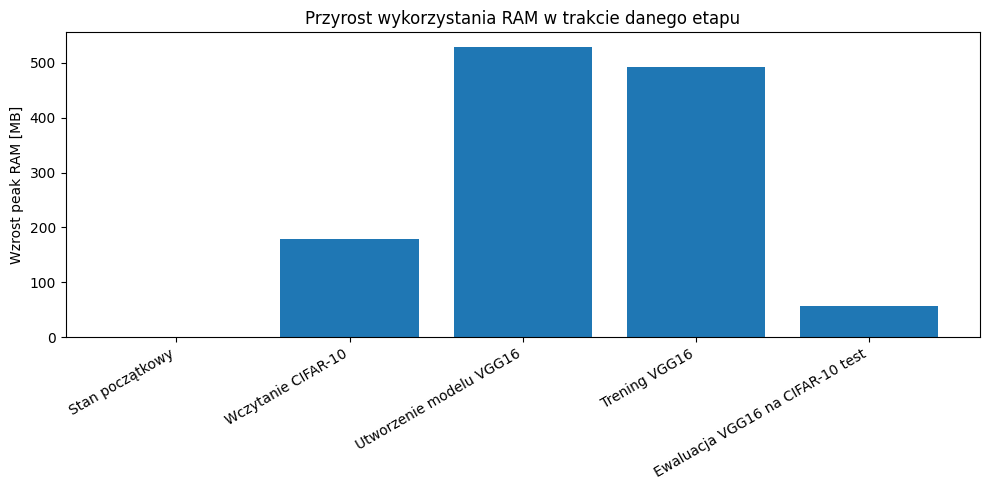

In [11]:
plt.figure(figsize=(10, 5))
plt.bar(memory_df["stage"], memory_df["ram_peak_increase_mb"])
plt.xticks(rotation=30, ha="right")
plt.ylabel("Wzrost peak RAM [MB]")
plt.title("Przyrost wykorzystania RAM w trakcie danego etapu")
plt.tight_layout()
plt.show()

## Wykres pamięci GPU

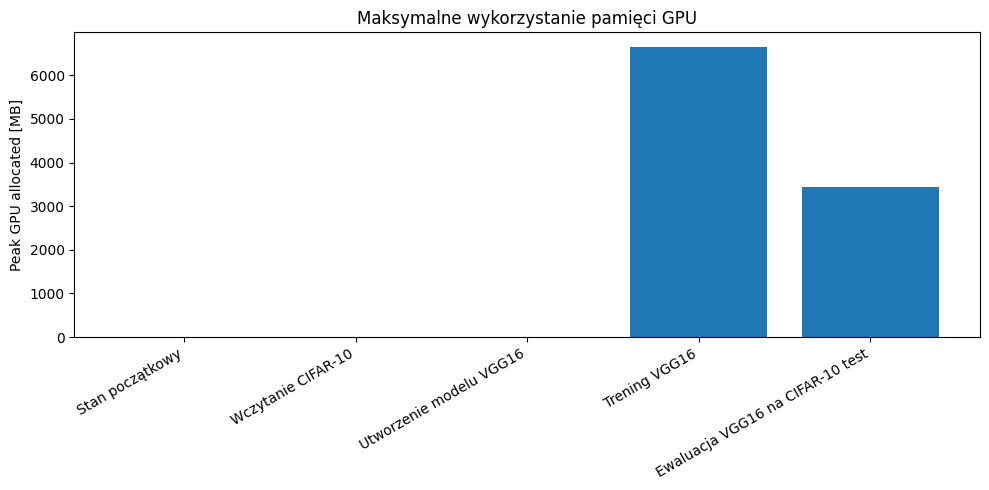

In [12]:
if memory_df["gpu_peak_allocated_mb"].notna().any():
    plt.figure(figsize=(10, 5))
    plt.bar(memory_df["stage"], memory_df["gpu_peak_allocated_mb"])
    plt.xticks(rotation=30, ha="right")
    plt.ylabel("Peak GPU allocated [MB]")
    plt.title("Maksymalne wykorzystanie pamięci GPU")
    plt.tight_layout()
    plt.show()
else:
    print("CUDA nie jest dostępna albo nie wykryto pomiarów GPU.")

## Podsumowanie

W eksperymencie przeprowadzono analizę wykorzystania pamięci RAM przez model VGG16 podczas pracy na zbiorze CIFAR-10. Pomiar wykonano dla kolejnych etapów: wczytania danych, utworzenia modelu, treningu oraz ewaluacji.

Dla każdego etapu zapisano pamięć przed rozpoczęciem operacji, pamięć po zakończeniu operacji oraz maksymalne zaobserwowane wykorzystanie pamięci w trakcie działania.